In [ ]:
# Install required libraries
'''
!pip install nilearn
!pip install torch
!pip install matplotlib
'''

'\n!pip install nilearn\n!pip install torch\n!pip install matplotlib\n'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

In [ ]:
# Cell 3: Unzip dataset and set dataset root

import os
import zipfile

ZIP_PATH = "/content/pooled_stratified_share.zip"
EXTRACT_PATH = "/content"

# unzip if folder does not already exist
if not os.path.exists("/content/pooled_stratified_share"):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

DATA_ROOT = "/content/pooled_stratified_share"

print("Dataset root directory:", DATA_ROOT)

# list subjects to confirm dataset loaded
subjects = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])

print("Number of subjects:", len(subjects))
print("Subjects detected:", subjects)

Unzipping dataset...
Dataset root directory: /content/pooled_stratified_share
Number of subjects: 8
Subjects detected: ['subjA2s60K-Hhm', 'subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjsRowSC6dc4', 'subjtySNgRhV65', 'subjxpYwO4azeZ']


In [ ]:
'''
# Cell 4: Split subjects into train and test groups

split_idx = 6

train_subjects = subjects[:split_idx]
test_subjects = subjects[split_idx:]

print("Train subjects:")
for s in train_subjects:
    print("  ", s)

print("\nTest subjects:")
for s in test_subjects:
    print("  ", s)
'''

'\n# Cell 4: Split subjects into train and test groups\n\nsplit_idx = 6\n\ntrain_subjects = subjects[:split_idx]\ntest_subjects = subjects[split_idx:]\n\nprint("Train subjects:")\nfor s in train_subjects:\n    print("  ", s)\n\nprint("\nTest subjects:")\nfor s in test_subjects:\n    print("  ", s)\n'

In [ ]:
# New Cell 4 for correct test/train as lin. reg.

import glob
import os
import numpy as np

npz_files = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.npz"), recursive=True))

print("Total run files found:", len(npz_files))

run_ids = np.arange(len(npz_files))

np.random.seed(42)
np.random.shuffle(run_ids)

split_idx = int(0.8 * len(run_ids))

train_run_ids = run_ids[:split_idx]
test_run_ids = run_ids[split_idx:]

train_files = [npz_files[i] for i in train_run_ids]
test_files = [npz_files[i] for i in test_run_ids]

print("Train runs:", len(train_files))
print("Test runs:", len(test_files))

Total run files found: 2880
Train runs: 2304
Test runs: 576


In [ ]:
# Cell 5: Load all runs for a given set of subjects
'''
import numpy as np
import os

TARGET_ROI = 19   # enforce consistent ROI dimension


def load_runs_from_subjects(subject_list, data_root):

    runs = []
    run_info = []

    for subj in subject_list:

        subj_path = os.path.join(data_root, subj)

        if not os.path.isdir(subj_path):
            continue

        # iterate through session folders
        for session in sorted(os.listdir(subj_path)):

            session_path = os.path.join(subj_path, session)

            if not os.path.isdir(session_path):
                continue

            # iterate through run files
            for fname in sorted(os.listdir(session_path)):

                if not fname.endswith(".npz"):
                    continue

                fpath = os.path.join(session_path, fname)

                data = np.load(fpath)

                # dataset stores timeseries as (ROI, time)
                ts = data["timeseries"]

                # convert to (time, ROI)
                ts = ts.T

                current_roi = ts.shape[1]

                if current_roi < TARGET_ROI:
                    # pad missing ROI with zeros
                    pad_width = TARGET_ROI - current_roi
                    padding = np.zeros((ts.shape[0], pad_width))
                    ts = np.concatenate([ts, padding], axis=1)

                elif current_roi > TARGET_ROI:
                    # truncate extra ROI if present
                    ts = ts[:, :TARGET_ROI]

                # Normalize across time

                mean = ts.mean(axis=0, keepdims=True)
                std = ts.std(axis=0, keepdims=True)

                ts = (ts - mean) / (std + 1e-8)

                # store run
                runs.append(ts)

                # store metadata for debugging
                run_info.append({
                    "subject": subj,
                    "session": session,
                    "file": fname,
                    "shape": ts.shape
                })

    return runs, run_info


# load train and test runs
train_runs, train_run_info = load_runs_from_subjects(train_subjects, DATA_ROOT)
test_runs, test_run_info = load_runs_from_subjects(test_subjects, DATA_ROOT)

print("Number of training runs:", len(train_runs))
print("Number of test runs:", len(test_runs))

if len(train_runs) > 0:
    print("Example training run shape:", train_runs[0].shape)

if len(test_runs) > 0:
    print("Example test run shape:", test_runs[0].shape)
    '''


'\nimport numpy as np\nimport os\n\nTARGET_ROI = 19   # enforce consistent ROI dimension\n\n\ndef load_runs_from_subjects(subject_list, data_root):\n\n    runs = []\n    run_info = []\n\n    for subj in subject_list:\n\n        subj_path = os.path.join(data_root, subj)\n\n        if not os.path.isdir(subj_path):\n            continue\n\n        # iterate through session folders\n        for session in sorted(os.listdir(subj_path)):\n\n            session_path = os.path.join(subj_path, session)\n\n            if not os.path.isdir(session_path):\n                continue\n\n            # iterate through run files\n            for fname in sorted(os.listdir(session_path)):\n\n                if not fname.endswith(".npz"):\n                    continue\n\n                fpath = os.path.join(session_path, fname)\n\n                data = np.load(fpath)\n\n                # dataset stores timeseries as (ROI, time)\n                ts = data["timeseries"]\n\n                # convert to (tim

In [ ]:
'''
train_runs = train_runs[:200]
test_runs = test_runs[:50]
'''

'\ntrain_runs = train_runs[:200]\ntest_runs = test_runs[:50]\n'

In [ ]:
# New Cell 5

import numpy as np
import os

TARGET_ROI = 18   # match linear notebook for roi = 18

def load_runs_from_filelist(file_list, target_roi=18, zscore=True):
    runs = []
    run_info = []

    for fpath in file_list:
        data = np.load(fpath)
        ts = data["timeseries"]   # shape: (ROI, time)

        # truncate to consistent ROI count
        ts = ts[:target_roi, :]

        # transpose to (time, ROI) for transformer
        ts = ts.T

        if zscore:
            mean = ts.mean(axis=0, keepdims=True)
            std = ts.std(axis=0, keepdims=True)
            ts = (ts - mean) / (std + 1e-8)

        runs.append(ts)
        run_info.append({
            "file": fpath,
            "shape": ts.shape
        })

    return runs, run_info

train_runs, train_run_info = load_runs_from_filelist(train_files, target_roi=TARGET_ROI)
test_runs, test_run_info = load_runs_from_filelist(test_files, target_roi=TARGET_ROI)

print("Number of training runs:", len(train_runs))
print("Number of test runs:", len(test_runs))
print("Example training run shape:", train_runs[0].shape if len(train_runs) > 0 else "none")

Number of training runs: 2304
Number of test runs: 576
Example training run shape: (226, 18)


**This model uses the exact same train/test split as the linear regression model by loading the saved train_files.npy and test_files.npy. This guarantees that both models are trained and evaluated on identical runs. Similar to the linear model, we construct sliding window samples from the test runs and compute loss over all batches in the test loader. This ensures a fair comparison since both models are evaluated on the same test data and prediction task.**

Cell 5 loads and standardizes the fMRI runs that will later be used for training and testing the forecasting model.

Each .npz file contains a matrix called "timeseries" representing ROI BOLD signals with shape (ROI, time). We transpoe it to (time, ROI) cuz the model I modified from requires that.
Some of them have 226x19 and some have 226x18 and could cause batching errors. I pad the missing ROI with 0.

The processed time-series arrays are stored in a list called runs, while additional metadata such as subject, session, file name, and resulting shape are saved in run_info for debugging and inspection

In [ ]:
# Cell 6: Quick sanity checks on loaded runs cuz I've seen 226x19 and 226x18

print("First 8 training run metadata entries:")
for info in train_run_info[:8]:
    print(info)

print("\nUnique shapes seen in training runs:")
unique_train_shapes = sorted(list(set([tuple(x.shape) for x in train_runs])))
print(unique_train_shapes)

print("\nUnique shapes seen in test runs:")
unique_test_shapes = sorted(list(set([tuple(x.shape) for x in test_runs])))
print(unique_test_shapes)

First 8 training run metadata entries:
{'file': '/content/pooled_stratified_share/subjOenz4SHyaO/session7RngtKNYNk/session7RngtKNYNk_runsRowSC6dc4.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjqFdsBbuiHF/session9cf_WBS7w_/session9cf_WBS7w__run61u38PxBQj.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjtySNgRhV65/sessiono9Qu0ckvUU/sessiono9Qu0ckvUU_runw2slwsLpY8.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjqFdsBbuiHF/sessionX90xpMsE8r/sessionX90xpMsE8r_runqFdsBbuiHF.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjQX6R7rImeb/sessionw2slwsLpY8/sessionw2slwsLpY8_runw2slwsLpY8.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjoVC0sHUB_P/sessionSYt_LrCf8l/sessionSYt_LrCf8l_runsRowSC6dc4.npz', 'shape': (226, 18)}
{'file': '/content/pooled_stratified_share/subjoVC0sHUB_P/session0BuHV4d9L3/session0BuHV4d9L3_runxpYwO4azeZ.npz', 'shape': (226, 18)}
{'file': '/content/pool

In [ ]:
'''
# Cell 7: Plot one example ROI signal from one run
# This is just to make sure the BOLD signal looks reasonable after loading.

import matplotlib.pyplot as plt

example_run = train_runs[0]

plt.figure(figsize=(12, 4))
plt.plot(example_run[:, 0])
plt.title("Example normalized BOLD signal for ROI 0")
plt.xlabel("Time index")
plt.ylabel("Z-scored BOLD")
plt.show()
'''

'\n# Cell 7: Plot one example ROI signal from one run\n# This is just to make sure the BOLD signal looks reasonable after loading.\n\nimport matplotlib.pyplot as plt\n\nexample_run = train_runs[0]\n\nplt.figure(figsize=(12, 4))\nplt.plot(example_run[:, 0])\nplt.title("Example normalized BOLD signal for ROI 0")\nplt.xlabel("Time index")\nplt.ylabel("Z-scored BOLD")\nplt.show()\n'

In [ ]:
# Cell 8: Forecasting parameters

WINDOW_SIZE = 30
PREDICT_STEP = 1      # predict the next timepoint only (we are using a sliding_window)
BATCH_SIZE = 256

I changed the batch size from 64 to 256, so that an epoch contains less batches (dataset/batch_size). Feel free to revert it back, but expect hours of training

In [ ]:
# Cell 9: Dataset class that converts runs into sliding-window samples

import torch
from torch.utils.data import Dataset

class FMRIDataset(Dataset):
    """
    Convert a list of runs into many (input_window, target_next_step) samples.

    Each run has shape:
        (time, ROI)

    Each sample is:
        x : (window_size, ROI)
        y : (ROI,)
    """

    def __init__(self, runs, window_size=30, predict_step=1):
        self.samples = []

        for run in runs:
            T = run.shape[0]

            # We need enough room for the input window plus the prediction target
            for t in range(T - window_size - predict_step + 1):
                x = run[t : t + window_size]
                y = run[t + window_size + predict_step - 1]

                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

In [ ]:
# Cell 10: Build train and test datasets from loaded runs

train_dataset = FMRIDataset(
    runs=train_runs,
    window_size=WINDOW_SIZE,
    predict_step=PREDICT_STEP
)

test_dataset = FMRIDataset(
    runs=test_runs,
    window_size=WINDOW_SIZE,
    predict_step=PREDICT_STEP
)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

Number of training samples: 451584
Number of test samples: 112896


In [ ]:
# Cell 11: DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
"""
# Diagnostic: check ROI dimensions across runs

roi_counts = []
example_files = []

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".npz"):
            path = os.path.join(root, f)
            data = np.load(path)

            ts = data["timeseries"]  # raw array

            roi_counts.append(ts.shape[0])  # ROI dimension
            example_files.append((path, ts.shape))

print("Unique ROI counts:", set(roi_counts))

print("\nExample files and shapes:")
for item in example_files[:10]:
    print(item)
"""

'\n# Diagnostic: check ROI dimensions across runs\n\nroi_counts = []\nexample_files = []\n\nfor root, dirs, files in os.walk(DATA_ROOT):\n    for f in files:\n        if f.endswith(".npz"):\n            path = os.path.join(root, f)\n            data = np.load(path)\n\n            ts = data["timeseries"]  # raw array\n\n            roi_counts.append(ts.shape[0])  # ROI dimension\n            example_files.append((path, ts.shape))\n\nprint("Unique ROI counts:", set(roi_counts))\n\nprint("\nExample files and shapes:")\nfor item in example_files[:10]:\n    print(item)\n'

In [ ]:
# Cell 12: Inspect one batch

x_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", x_batch.shape)   # expected: (batch, window, ROI)
print("Target batch shape:", y_batch.shape)  # expected: (batch, ROI)

Input batch shape: torch.Size([256, 30, 18])
Target batch shape: torch.Size([256, 18])


In [ ]:
# Cell 13: Transformer forecasting model

import torch.nn as nn

class TransformerForecastModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()

        # Project ROI features into transformer hidden dimension
        self.input_proj = nn.Linear(input_dim, d_model)

        # Learnable positional embedding for sequence order
        # We only need enough positions for WINDOW_SIZE
        self.pos_embedding = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Final linear layer maps hidden state back to ROI dimension
        self.output_layer = nn.Linear(d_model, input_dim)

    def forward(self, x):
        """
        x shape: (batch, window, ROI)
        """
        x = self.input_proj(x)                        # (batch, window, d_model)
        x = x + self.pos_embedding[:, :x.size(1), :] # add positional info
        x = self.transformer_encoder(x)               # (batch, window, d_model)

        # Use the final time step representation to predict the next brain state
        x_last = x[:, -1, :]                         # (batch, d_model)
        out = self.output_layer(x_last)              # (batch, ROI)

        return out

In [ ]:
# Cell 14: Initialize model and device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = x_batch.shape[-1]

model = TransformerForecastModel(
    input_dim=input_dim,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1
).to(device)

print(model)

Using device: cuda
TransformerForecastModel(
  (input_proj): Linear(in_features=18, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=18, bias=True)
)


In [ ]:
# Cell 15: Loss function and optimizer

import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [ ]:
print("Train runs:", len(train_runs))
print("Test runs:", len(test_runs))

print("Train dataset samples:", len(train_dataset))
print("Test dataset samples:", len(test_dataset))

train_dataset/train_runs

NameError: name 'train_runs' is not defined

In [ ]:
# Cell 16: Training loop with progress printing and timing

import time
import math

EPOCHS = 5

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # =========================
    # Training
    # =========================
    model.train()
    running_train_loss = 0.0
    train_batch_start = time.time()

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # print every 100 batches so you know it's still alive
        if batch_idx % 100 == 0 or batch_idx == len(train_loader) - 1:
            batches_done = batch_idx + 1
            elapsed = time.time() - train_batch_start
            sec_per_batch = elapsed / batches_done
            batches_left = len(train_loader) - batches_done
            eta_sec = sec_per_batch * batches_left

            print(
                f"[Epoch {epoch+1:02d}] "
                f"Train Batch {batches_done:4d}/{len(train_loader)} | "
                f"Batch Loss: {loss.item():.6f} | "
                f"Avg So Far: {running_train_loss / batches_done:.6f} | "
                f"ETA: {eta_sec/60:.1f} min"
            )

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # =========================
    # Evaluation
    # =========================
    model.eval()
    running_test_loss = 0.0
    test_batch_start = time.time()

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(test_loader):
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            running_test_loss += loss.item()

            if batch_idx % 50 == 0 or batch_idx == len(test_loader) - 1:
                batches_done = batch_idx + 1
                elapsed = time.time() - test_batch_start
                sec_per_batch = elapsed / batches_done
                batches_left = len(test_loader) - batches_done
                eta_sec = sec_per_batch * batches_left

                print(
                    f"[Epoch {epoch+1:02d}] "
                    f"Test  Batch {batches_done:4d}/{len(test_loader)} | "
                    f"Batch Loss: {loss.item():.6f} | "
                    f"Avg So Far: {running_test_loss / batches_done:.6f} | "
                    f"ETA: {eta_sec/60:.1f} min"
                )

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    epoch_time = time.time() - epoch_start_time

    print("=" * 80)
    print(
        f"Epoch {epoch+1:02d} Complete | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Test Loss: {avg_test_loss:.6f} | "
        f"Epoch Time: {epoch_time/60:.2f} min"
    )
    print("=" * 80)

[Epoch 01] Train Batch    1/1764 | Batch Loss: 1.205277 | Avg So Far: 1.205277 | ETA: 23.9 min
[Epoch 01] Train Batch  101/1764 | Batch Loss: 0.545623 | Avg So Far: 0.640107 | ETA: 0.8 min
[Epoch 01] Train Batch  201/1764 | Batch Loss: 0.502417 | Avg So Far: 0.586723 | ETA: 0.6 min
[Epoch 01] Train Batch  301/1764 | Batch Loss: 0.507778 | Avg So Far: 0.565975 | ETA: 0.5 min
[Epoch 01] Train Batch  401/1764 | Batch Loss: 0.503493 | Avg So Far: 0.553650 | ETA: 0.5 min
[Epoch 01] Train Batch  501/1764 | Batch Loss: 0.476443 | Avg So Far: 0.545110 | ETA: 0.5 min
[Epoch 01] Train Batch  601/1764 | Batch Loss: 0.482667 | Avg So Far: 0.538733 | ETA: 0.4 min
[Epoch 01] Train Batch  701/1764 | Batch Loss: 0.492711 | Avg So Far: 0.534054 | ETA: 0.4 min
[Epoch 01] Train Batch  801/1764 | Batch Loss: 0.499516 | Avg So Far: 0.530219 | ETA: 0.3 min
[Epoch 01] Train Batch  901/1764 | Batch Loss: 0.485516 | Avg So Far: 0.526738 | ETA: 0.3 min
[Epoch 01] Train Batch 1001/1764 | Batch Loss: 0.529227 | A

Epoch started as 20. Took hours. Forgot to save. So changed to 5. Revert if you want

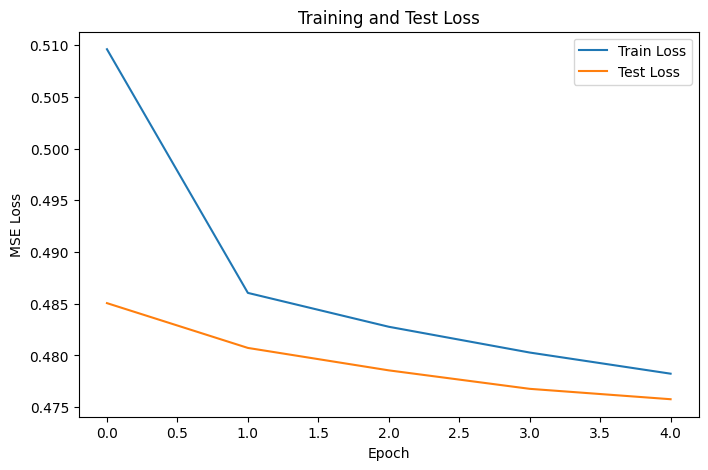

In [ ]:
# Cell 17: Plot train/test loss curves

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

In linear regression, time-series data is parsed by flattening a sliding window into a single feature vector, so temporal structure is manually encoded
In transformers, the same sliding window is kept as a sequence, allowing the model to directly learn temporal dependencies through self-attention
Linear models treat time steps as independent features, while transformers explicitly model relationships across time

In [ ]:
# Cell 18: Collect predictions and ground truth on the test set

model.eval()

all_preds = []
all_truth = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        pred = model(x).cpu().numpy()
        truth = y.numpy()

        all_preds.append(pred)
        all_truth.append(truth)

all_preds = np.concatenate(all_preds, axis=0)
all_truth = np.concatenate(all_truth, axis=0)

print("Predictions shape:", all_preds.shape)
print("Ground truth shape:", all_truth.shape)

Predictions shape: (112896, 18)
Ground truth shape: (112896, 18)


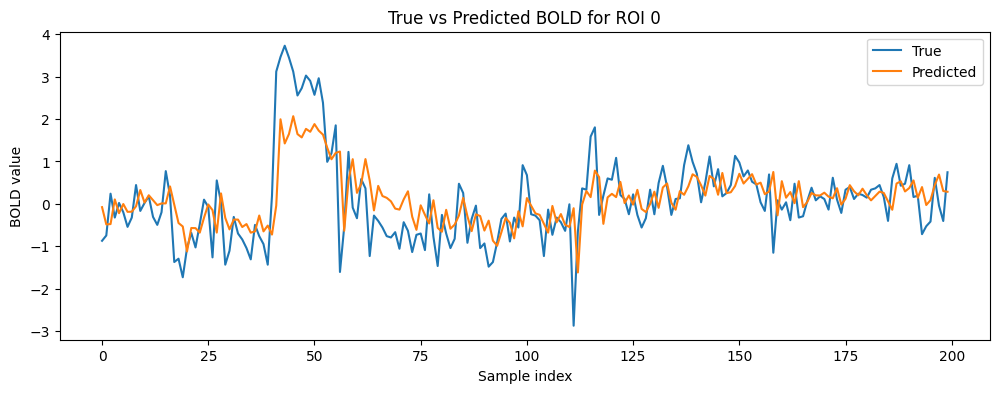

In [ ]:
# Cell 19: Compare true vs predicted signal for one ROI

roi_idx = 0
num_points = 200

plt.figure(figsize=(12, 4))
plt.plot(all_truth[:num_points, roi_idx], label="True")
plt.plot(all_preds[:num_points, roi_idx], label="Predicted")
plt.xlabel("Sample index")
plt.ylabel("BOLD value")
plt.title(f"True vs Predicted BOLD for ROI {roi_idx}")
plt.legend()
plt.show()

In [ ]:
# Cell 20: Compute correlation for each ROI

roi_corrs = []

for roi_idx in range(all_truth.shape[1]):
    true_roi = all_truth[:, roi_idx]
    pred_roi = all_preds[:, roi_idx]

    # Guard against degenerate constant arrays
    if np.std(true_roi) < 1e-8 or np.std(pred_roi) < 1e-8:
        corr = np.nan
    else:
        corr = np.corrcoef(true_roi, pred_roi)[0, 1]

    roi_corrs.append(corr)

roi_corrs = np.array(roi_corrs)

print("Per-ROI correlations:")
print(roi_corrs)

print("\nMean ROI correlation:", np.nanmean(roi_corrs))

Per-ROI correlations:
[0.56059559 0.6244406  0.62470484 0.80271206 0.55912423 0.73949401
 0.57038425 0.55517259 0.54836675 0.54652853 0.57829148 0.86245332
 0.8216625  0.89378758 0.73961905 0.84628028 0.62832721 0.70242307]

Mean ROI correlation: 0.6780204409060664


# **Statistics**

In [ ]:
# CELL 21: ORGANIZE TEST PREDICTIONS
# This cell stores the transformer test predictions and true test values
# in consistent variable names so the later statistics cells match
# the structure used in the linear regression notebook.

Y_test_all = all_truth.copy()
Y_pred_all = all_preds.copy()

print("Y_test_all shape:", Y_test_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)

Y_test_all shape: (112896, 18)
Y_pred_all shape: (112896, 18)


In [ ]:
# CELL 22: RECONSTRUCT TEST SAMPLE RUN IDS
# This cell rebuilds the run ID for each test sample.
# The transformer dataset creates sliding-window samples by looping through
# each test run in order, and test_loader uses shuffle=False, so the predictions
# stay in that same order.
#
# That means we can assign each test sample back to its original run by counting
# how many sliding-window samples each test run contributed.

test_sample_run_ids = []
test_run_sample_counts = []

for run_idx, run in enumerate(test_runs):
    T = run.shape[0]
    num_samples = T - WINDOW_SIZE - PREDICT_STEP + 1

    test_sample_run_ids.extend([run_idx] * num_samples)
    test_run_sample_counts.append(num_samples)

test_sample_run_ids = np.array(test_sample_run_ids)
test_run_sample_counts = np.array(test_run_sample_counts)

print("test_sample_run_ids shape:", test_sample_run_ids.shape)
print("Number of held-out test runs:", len(np.unique(test_sample_run_ids)))
print("Total reconstructed test samples:", len(test_sample_run_ids))
print("Matches Y_test_all length:", len(test_sample_run_ids) == len(Y_test_all))

test_sample_run_ids shape: (112896,)
Number of held-out test runs: 576
Total reconstructed test samples: 112896
Matches Y_test_all length: True


In [ ]:
# CELL 23: OVERALL TEST MSE AND SCALED MSE
# This cell computes:
# 1. Overall test MSE across all ROIs and all test samples
# 2. A scaled MSE using the average squared one-step difference from the training runs
#
# The scaled MSE helps show model error relative to the natural size
# of step-to-step changes in the training signal.

from sklearn.metrics import mean_squared_error

# Overall MSE across all samples and all ROIs
overall_mse = mean_squared_error(Y_test_all, Y_pred_all)

# Scaling denominator from TRAIN runs only
train_naive_sq_diffs = []

for run in train_runs:
    diffs = np.diff(run, axis=0)   # run shape: (time, ROI)
    train_naive_sq_diffs.append(diffs**2)

train_naive_sq_diffs = np.concatenate(
    [arr.reshape(-1) for arr in train_naive_sq_diffs]
)

scale_denom = np.mean(train_naive_sq_diffs)
scaled_mse = overall_mse / scale_denom

print("Overall Test MSE:", overall_mse)
print("Scale Denominator (train naive diff^2 mean):", scale_denom)
print("Scaled MSE:", scaled_mse)

Overall Test MSE: 0.47575485706329346
Scale Denominator (train naive diff^2 mean): 0.671079157047519
Scaled MSE: 0.7089399992043045


In [ ]:
# CELL 24: PER-ROI PERFORMANCE STATISTICS
# This cell computes test MSE separately for each ROI.
# It helps us see whether the transformer performs similarly across ROIs
# or if some brain regions are easier or harder to predict.

roi_mse = np.mean((Y_test_all - Y_pred_all) ** 2, axis=0)

print("Per-ROI MSE:")
for roi_idx, val in enumerate(roi_mse):
    print(f"ROI {roi_idx}: {val:.6f}")

print("\nSummary across ROIs:")
print("Mean ROI MSE:", np.mean(roi_mse))
print("Std ROI MSE:", np.std(roi_mse))
print("Best ROI MSE:", np.min(roi_mse))
print("Worst ROI MSE:", np.max(roi_mse))

Per-ROI MSE:
ROI 0: 0.635525
ROI 1: 0.564615
ROI 2: 0.555064
ROI 3: 0.315391
ROI 4: 0.491856
ROI 5: 0.410883
ROI 6: 0.621768
ROI 7: 0.643706
ROI 8: 0.661555
ROI 9: 0.662307
ROI 10: 0.631221
ROI 11: 0.228054
ROI 12: 0.289438
ROI 13: 0.187884
ROI 14: 0.422162
ROI 15: 0.268461
ROI 16: 0.500406
ROI 17: 0.473292

Summary across ROIs:
Mean ROI MSE: 0.47575486
Std ROI MSE: 0.15604724
Best ROI MSE: 0.18788353
Worst ROI MSE: 0.6623066


In [ ]:
# CELL 25: RUN-LEVEL PERFORMANCE ACROSS HELD-OUT TEST RUNS
# This cell computes one MSE value per held-out test run.
# Each test run contributes many sliding-window samples, and we group
# those samples back together using the reconstructed run IDs.

unique_test_runs = np.unique(test_sample_run_ids)

run_level_mse = []
run_level_num_samples = []

for run_id in unique_test_runs:
    run_mask = (test_sample_run_ids == run_id)

    y_true_run = Y_test_all[run_mask]
    y_pred_run = Y_pred_all[run_mask]

    mse_run = mean_squared_error(y_true_run, y_pred_run)

    run_level_mse.append(mse_run)
    run_level_num_samples.append(np.sum(run_mask))

run_level_mse = np.array(run_level_mse)
run_level_num_samples = np.array(run_level_num_samples)

print("Run-level MSE for each held-out test run:")
for i, run_id in enumerate(unique_test_runs):
    print(f"Run {run_id}: MSE = {run_level_mse[i]:.6f} | Samples = {run_level_num_samples[i]}")

print("\nRun-level summary:")
print("Mean run MSE:", np.mean(run_level_mse))
print("Std run MSE:", np.std(run_level_mse))
print("Best run MSE:", np.min(run_level_mse))
print("Worst run MSE:", np.max(run_level_mse))

Run-level MSE for each held-out test run:
Run 0: MSE = 0.495530 | Samples = 196
Run 1: MSE = 0.437543 | Samples = 196
Run 2: MSE = 0.437047 | Samples = 196
Run 3: MSE = 0.404250 | Samples = 196
Run 4: MSE = 0.593741 | Samples = 196
Run 5: MSE = 0.420752 | Samples = 196
Run 6: MSE = 0.401548 | Samples = 196
Run 7: MSE = 0.555598 | Samples = 196
Run 8: MSE = 0.398750 | Samples = 196
Run 9: MSE = 0.423102 | Samples = 196
Run 10: MSE = 0.445294 | Samples = 196
Run 11: MSE = 0.435981 | Samples = 196
Run 12: MSE = 0.339930 | Samples = 196
Run 13: MSE = 0.501905 | Samples = 196
Run 14: MSE = 0.645849 | Samples = 196
Run 15: MSE = 0.546351 | Samples = 196
Run 16: MSE = 0.424955 | Samples = 196
Run 17: MSE = 0.503862 | Samples = 196
Run 18: MSE = 0.341477 | Samples = 196
Run 19: MSE = 0.435001 | Samples = 196
Run 20: MSE = 0.498610 | Samples = 196
Run 21: MSE = 0.505200 | Samples = 196
Run 22: MSE = 0.628237 | Samples = 196
Run 23: MSE = 0.577820 | Samples = 196
Run 24: MSE = 0.515854 | Samples

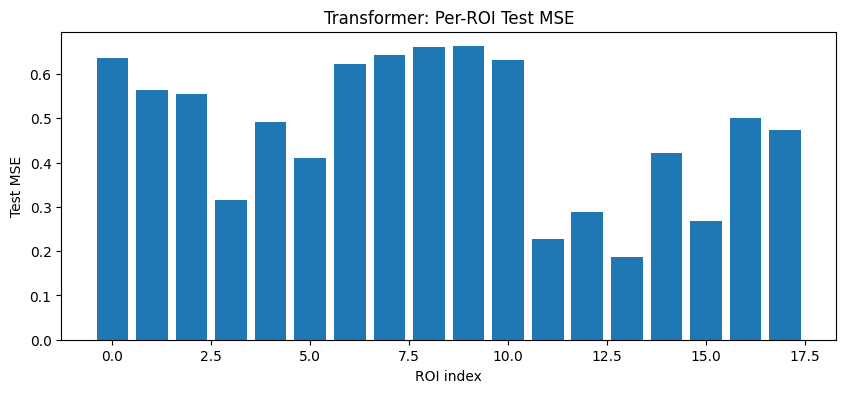

In [ ]:
# CELL 26: PLOT PER-ROI MSE
# This plot shows how transformer prediction error changes across ROIs.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(roi_mse)), roi_mse)
plt.xlabel("ROI index")
plt.ylabel("Test MSE")
plt.title("Transformer: Per-ROI Test MSE")
plt.show()

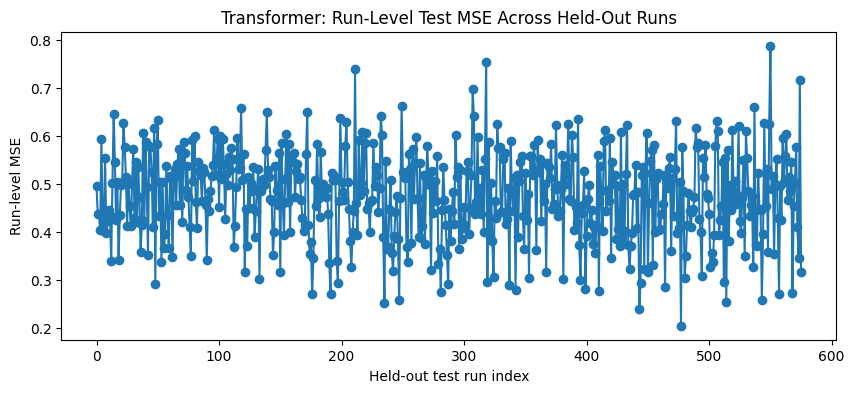

In [ ]:
# CELL 27: PLOT RUN-LEVEL MSE
# This plot shows how transformer performance varies across held-out test runs.

plt.figure(figsize=(10, 4))
plt.plot(run_level_mse, marker='o')
plt.xlabel("Held-out test run index")
plt.ylabel("Run-level MSE")
plt.title("Transformer: Run-Level Test MSE Across Held-Out Runs")
plt.show()

In [ ]:
# CELL 28: SAVE TRANSFORMER STATISTICS FOR LATER MODEL COMPARISON
# This cell saves the transformer outputs and summary statistics using
# the same key names as the linear regression notebook, so both files
# can be loaded easily into one separate comparison notebook later.

transformer_results = {
    "model_name": "Transformer",
    "window_size": WINDOW_SIZE,
    "horizon": PREDICT_STEP,
    "num_rois": TARGET_ROI,

    "overall_mse": overall_mse,
    "scaled_mse": scaled_mse,

    "roi_mse": roi_mse,
    "mean_roi_mse": np.mean(roi_mse),
    "std_roi_mse": np.std(roi_mse),

    "run_level_mse": run_level_mse,
    "mean_run_mse": np.mean(run_level_mse),
    "std_run_mse": np.std(run_level_mse),

    "Y_test_all": Y_test_all,
    "Y_pred_all": Y_pred_all,
    "test_sample_run_ids": test_sample_run_ids,
    "test_runs": unique_test_runs
}

np.save("/content/transformer_statistics.npy", transformer_results, allow_pickle=True)

print("Saved to: /content/transformer_statistics.npy")

Saved to: /content/transformer_statistics.npy
